In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
open_df = pd.read_csv("openmp_results.csv")
open_df.head()

,Type,Size,Threads,ComputationTimeMs,ExecutionTimeMs,DataTransferTimeMs,Throughput,Speedup,Sorted
0,Sequential,10000,1,177.862,177.862,0.000,56223.33,1.00,Yes
1,OpenMP,10000,2,437.257,437.319,0.061,22869.83,0.41,Yes
2,OpenMP,10000,4,415.506,415.564,0.058,24067.04,0.43,Yes
3,OpenMP,10000,8,555.209,555.271,0.062,18011.23,0.32,Yes
4,OpenMP,10000,16,1189.404,1189.465,0.060,8407.57,0.15,Yes


In [6]:
mean_df = (
    open_df.groupby(["Type", "Size", "Threads"], as_index=False)
      .agg(
          ComputationTimeMs_mean=("ComputationTimeMs", "mean"),
          ExecutionTimeMs_mean=("ExecutionTimeMs", "mean"),
          DataTransferTimeMs_mean=("DataTransferTimeMs", "mean"),
          Throughput_mean=("Throughput", "mean"),
          Speedup_mean=("Speedup", "mean"),
          Sorted=("Sorted", "first")
      )
)

mean_df

,Type,Size,Threads,ComputationTimeMs_mean,ExecutionTimeMs_mean,DataTransferTimeMs_mean,Throughput_mean,Speedup_mean,Sorted
0,OpenMP,10000,2,441.319000,441.393000,0.073333,23053.573333,0.423333,Yes
1,OpenMP,10000,4,342.537333,342.593667,0.056333,30030.166667,0.550000,Yes
2,OpenMP,10000,8,536.420000,536.475000,0.055000,18833.640000,0.343333,Yes
3,OpenMP,10000,16,1203.726333,1203.793000,0.066333,8579.230000,0.156667,Yes
4,OpenMP,100000,2,30938.380333,30939.122333,0.742333,3304.973333,0.946667,Yes
5,OpenMP,100000,4,23034.398333,23035.438000,1.039333,4517.846667,1.286667,Yes
6,OpenMP,100000,8,18637.523000,18638.591667,1.068333,5524.500000,1.580000,Yes
7,OpenMP,100000,16,16922.778000,16923.897667,1.120000,6726.826667,1.910000,Yes
8,OpenMP,200000,2,114581.745000,114583.124000,1.379000,1756.446667,1.090000,Yes
9,OpenMP,200000,4,82293.516333,82295.630667,2.114333,2436.103333,1.516667,Yes


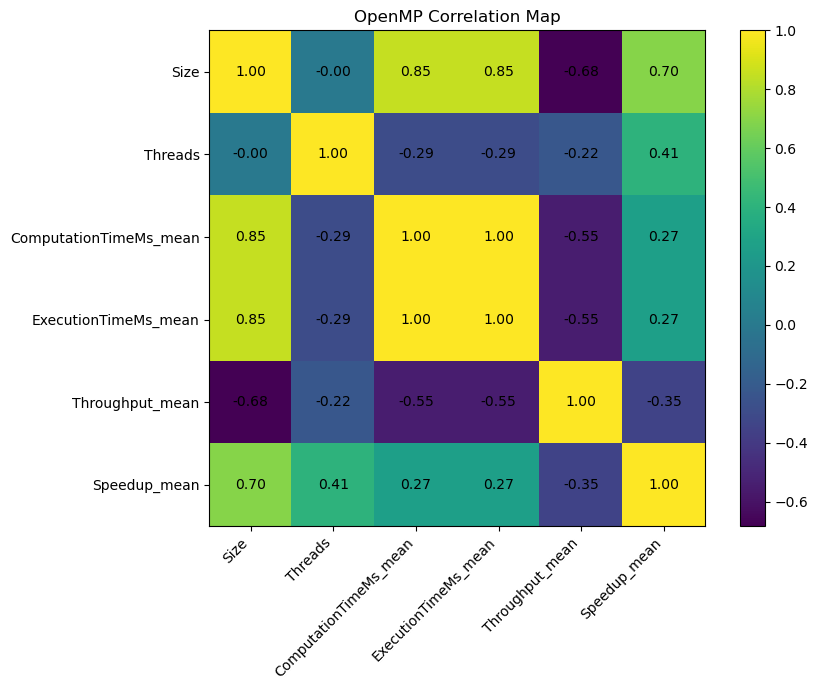

In [9]:
corr_data = mean_df[
    [
        "Size",
        "Threads",
        "ComputationTimeMs_mean",
        "ExecutionTimeMs_mean",
        "Throughput_mean",
        "Speedup_mean"
    ]
]

corr_matrix = corr_data.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# values inside cells
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("OpenMP Correlation Map")
plt.tight_layout()

# save image
plt.savefig("../images/openmp_correlation_map.png", dpi=300, bbox_inches="tight")

plt.show()

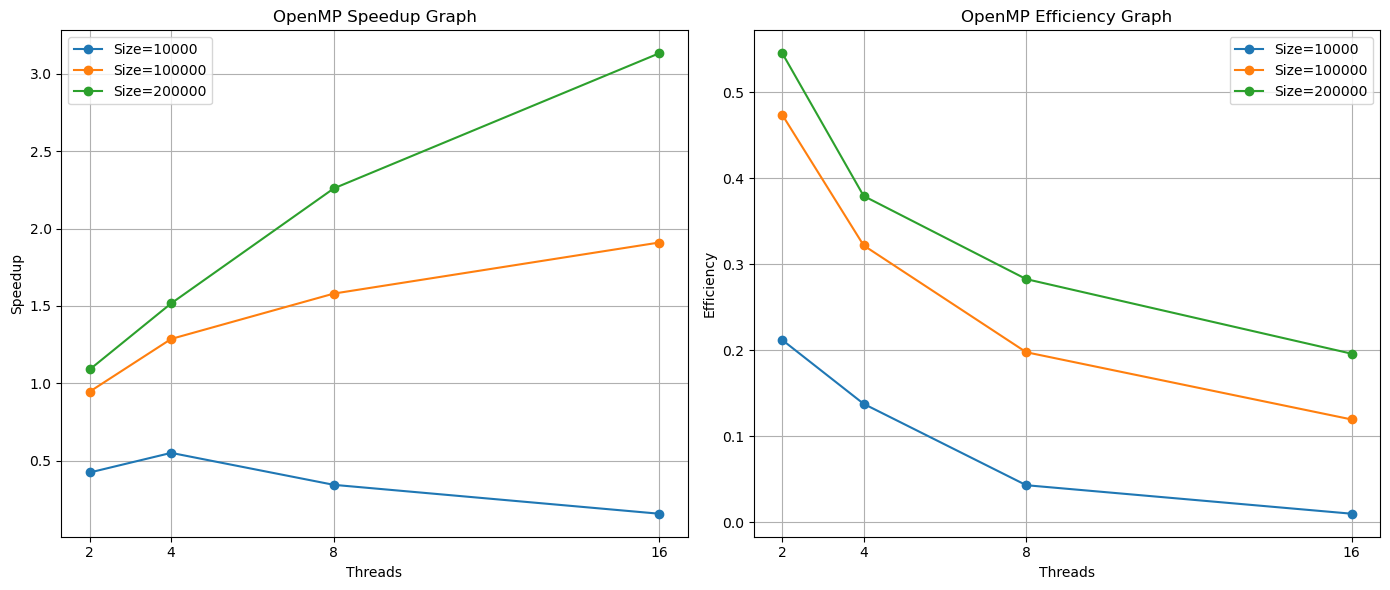

In [11]:
plot_df = mean_df.copy()

# Keep only OpenMP rows for plotting
plot_df = plot_df[plot_df["Type"] == "OpenMP"].copy()

# Efficiency = Speedup / Threads
plot_df["Efficiency_mean"] = plot_df["Speedup_mean"] / plot_df["Threads"]

# Sort values
plot_df = plot_df.sort_values(["Size", "Threads"])

sizes = sorted(plot_df["Size"].unique())
threads = sorted(plot_df["Threads"].unique())

# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Subplot 1: Speedup
# -----------------------------
for size in sizes:
    subset = plot_df[plot_df["Size"] == size]
    axes[0].plot(
        subset["Threads"],
        subset["Speedup_mean"],
        marker='o',
        label=f"Size={size}"
    )

axes[0].set_title("OpenMP Speedup Graph")
axes[0].set_xlabel("Threads")
axes[0].set_ylabel("Speedup")
axes[0].set_xticks(threads)
axes[0].grid(True)
axes[0].legend()

# -----------------------------
# Subplot 2: Efficiency
# -----------------------------
for size in sizes:
    subset = plot_df[plot_df["Size"] == size]
    axes[1].plot(
        subset["Threads"],
        subset["Efficiency_mean"],
        marker='o',
        label=f"Size={size}"
    )

axes[1].set_title("OpenMP Efficiency Graph")
axes[1].set_xlabel("Threads")
axes[1].set_ylabel("Efficiency")
axes[1].set_xticks(threads)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/openmp_speedup_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()